## EEG During mental arithmetic

This data has been extracted from https://physionet.org/content/eegmat/1.0.0/
Original publication: https://physionet.org/content/eegmat/1.0.0/

Otra fuente posible: https://openneuro.org/

In [1]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Initial raw data exploration

In [2]:
subject_info = pd.read_csv("../../data/EEG/subject-info.csv")
subject_info.head() # ---> Get classes for MEDA visualization from here.

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0


In [3]:
subject_ids             = subject_info["Subject"].to_numpy(dtype=str)
subject_ages            = subject_info["Age"].to_numpy(dtype=int)
subject_genders         = subject_info["Gender"].to_numpy(dtype=str)
subject_rec_years       = subject_info["Recording year"].to_numpy(dtype=int)
subject_n_subtractions  = subject_info["Number of subtractions"].to_numpy(dtype=float)
subject_quality         = subject_info["Count quality"].to_numpy(dtype=int)
operations = [1, 2]
operation_labels = ["Baseline", "Arithmetic"]

In [4]:
subject_id = subject_ids[10]
operation = operations[0]
file = f"../../data/EEG/{subject_id}_{operation}.edf"
data = mne.io.read_raw_edf(file)
raw_data = data.get_data()[:, 0:]
info = data.info
channels = data.ch_names

Extracting EDF parameters from ../../data/EEG/Subject10_1.edf...
Setting channel info structure...
Creating raw.info structure...


In [5]:
print(f"There are:\n - {len(subject_ids)} subjects. \n - {len(channels)} channels. \nSampling rate: 500.0Hz")

There are:
 - 36 subjects. 
 - 21 channels. 
Sampling rate: 500.0Hz


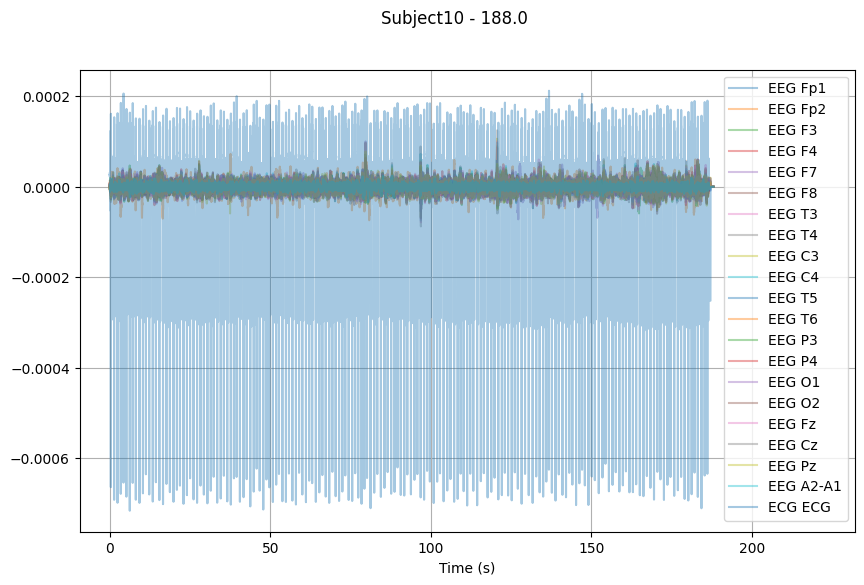

In [6]:

test_signal = raw_data[:, :].T
time = np.linspace(0, test_signal.shape[0]/500, test_signal.shape[0])
fig, ax = plt.subplots(1,1, figsize=(10,6))
fig.suptitle(f"{subject_id} - {raw_data.shape[1]/500.0}")
ax.plot(time, test_signal, label=channels, alpha=0.4)
ax.grid(True)
ax.legend()
ax.set_xlabel("Time (s)");
xlim = ax.get_xlim()
ax.set_xlim(xlim[0], xlim[1]*1.175);
# ax.set_xlim(182, 195);


### Build tensor

Tensor: individuo $\times$ channel $\times$ operación $\times$ tiempo $\times$ frecuencias 

Dimensiones: 36 $\times$ 21 $\times$  2 $\times$ T $\times$ F


In [7]:
import mne
import numpy as np
from msa.feature_extraction.features import *

In [8]:
# STFT parameters
sr = 500.0 # Hz
win_samples = int(0.50*sr) # samples
hop = int(win_samples//2) # samples
window = "blackman"
padding = "zeros"

max_signal_lenght = 188*500
n_windows = get_n_windows(np.zeros(max_signal_lenght), sr, win_samples, hop, window, padding)
n_frequencies = get_n_frequencies(sr, win_samples, hop, window, padding)
times = get_times(np.zeros(max_signal_lenght), sr, win_samples, hop, window, padding)


In [ ]:
X_tensor = np.full((len(subject_ids), len(channels), len(operations), n_windows, n_frequencies, ), np.nan)
print(f"Tensor dimension: {X_tensor.shape}")
for i, operation in enumerate(operations[:]):
    for j, subject_id in enumerate(subject_ids[:]):
            file = f"../../data/EEG/{subject_id}_{operation}.edf"
            data = mne.io.read_raw_edf(file)
            raw_data = data.get_data()[:, :]
            raw_data = raw_data[:, 0:raw_data.shape[0]-2000] # Quitamos los últimos segundos, que son artificios.
            channels = data.ch_names

            for k, signal in enumerate(raw_data):
                  # if signal.shape[0] > M:
                        # M = signal.shape[0]
                        # temp = [i,j,k]
                _, freq, Zxx = spectrogram(signal, sr, win_samples, hop, window, padding)
                Zxx = Zxx.T
                Zxx = Zxx[:n_windows, :n_frequencies]
                X_tensor[j, k, i,:Zxx.shape[0], :Zxx.shape[1]] = Zxx

Tensor dimension: (36, 21, 2, 753, 126)
Extracting EDF parameters from ../../data/EEG/Subject00_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject01_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject02_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject03_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject04_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject05_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subject06_1.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ../../data/EEG/Subj

In [ ]:
np.savez("../../data/EEG/data.npz",
         X_tensor=X_tensor,
         n_windows = n_windows,
         times = times,
         freqs = freq,
         channels = channels,
         subject_ids = subject_ids,
         subject_ages = subject_ages,
         subject_genders = subject_genders,
         subject_rec_years = subject_rec_years,
         subject_n_subtractions = subject_n_subtractions,
         subject_quality = subject_quality,
         operations = operations,
         operation_labels = operation_labels)
X_tensor.shape

(36, 21, 2, 1519, 63)

## MEDA Exploration

In [ ]:
from msa.feature_extraction.features import *
import numpy as np

In [ ]:
res = np.load("../../data/EEG/data.npz")
X_tensor = res["X_tensor"]
times                   = res["times"]
freqs                   = res["freqs"]
channels                = res["channels"]
subject_ids             = res["subject_ids"]
subject_ages            = res["subject_ages"]
subject_genders         = res["subject_genders"]
subject_rec_years       = res["subject_rec_years"]
subject_n_subtractions  = res["subject_n_subtractions"]
subject_quality         = res["subject_quality"]
operations              = res["operations"]
operation_labels        = res["operation_labels"]

X_tensor.shape

(36, 21, 2, 1519, 63)

#### Spectrogram visualization

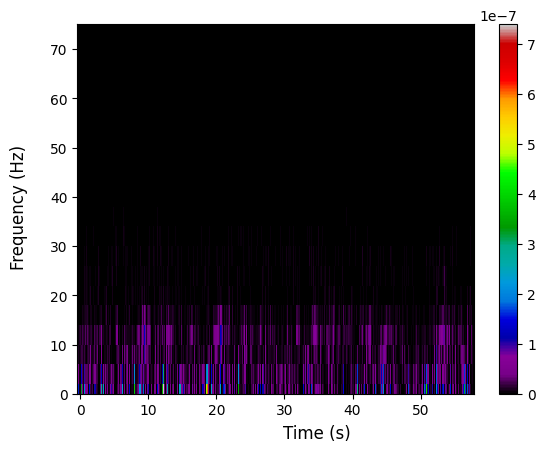

In [ ]:
from msa.visualization import plot
aux = X_tensor[10, 6, 1,:,:] # Subject, Channel, Operation, times, freqs

# Solo conserva filas que NO tengan ningún NaN
aux = aux[~np.isnan(aux).any(axis=1)]

fig, ax , _ = plot.spectrogram(times[:aux.shape[0]], freqs, aux.T, logscale=False);
ax.set_ylim(0, 75);

### Normalization
Tiene sentido normalizar tanto los canales como los sujetos

In [ ]:
# Block scaling
X_norm = X_tensor.copy();
for i in range(X_tensor.shape[1]):
    aux = X_norm[:, i, :, :, :]
    mu = np.nanmean(aux)
    sigma = np.nanstd(aux)
    X_norm[:, i, :, :, :] = (aux - mu)/sigma


n_subjects, n_channels, n_operations, n_times, n_freqs = X_norm.shape

### Unfolding

rows: (subject $\times$ operation $\times$ time)

columns: (channel $\times$ freqs)


In [ ]:
X_transposed = X_norm.transpose(0, 2, 3, 1, 4)
X_unfold = X_transposed.reshape(n_subjects * n_operations * n_times, n_channels * n_freqs)

repeats = n_operations*n_times
F_subject = np.repeat(subject_ids, repeats)
F_ages = np.repeat(subject_ages, repeats)
F_genders = np.repeat(subject_genders, repeats)
F_rec_years = np.repeat(subject_rec_years, repeats)
F_n_subtractions = np.repeat(subject_n_subtractions, repeats)
F_quality = np.repeat(subject_quality, repeats)
F_operations = np.repeat(operations, n_subjects*n_times)

freqs = np.tile(freqs, len(channels))
channels = np.repeat(channels, n_freqs)

#### Remove NaN rows

In [ ]:
idx = ~np.isnan(X_unfold).any(axis=1)

X_unfold = X_unfold[idx]
F_subject = F_subject[idx]
F_ages = F_ages[idx]
F_genders = F_genders[idx]
F_rec_years = F_rec_years[idx]
F_n_subtractions = F_n_subtractions[idx]
F_quality = F_quality[idx]
F_operations = F_operations[idx]

### MEDA Visualization

In [ ]:
from scipy.io import savemat


In [ ]:

data_dict = {
    'X_unfold': X_unfold,
    'F_subject': F_subject,
    'F_ages': F_ages,
    'F_genders': F_genders,
    'F_rec_years': F_rec_years,
    'F_n_subtractions': F_n_subtractions,
    'F_quality': F_quality,
    'F_operations': F_operations,

    'freqs': freqs,
    'channels': channels
}

savemat("../../data/EEG/EEG.mat", data_dict)
